# Playground Series S6E9 - Will_Buy_EV

Binary classification, submission is a probability, metric ROC AUC.

Logic lives in `s6e9.py`; this notebook runs read -> train -> test and writes `submission.csv`.

On Kaggle: upload `s6e9.py` as a Dataset (or Utility Script) and add it as an input.

In [25]:
import sys
from pathlib import Path
for p in Path("/kaggle/input").glob("*/s6e9.py") if Path("/kaggle/input").exists() else []:
    sys.path.append(str(p.parent))

from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

import pandas as pd
import s6e9 as s

pd.set_option("display.width", 200)

## Read - Baseline EDA

In [18]:
train, test = s.read_all()
print(train.shape, test.shape)
print(train[s.TARGET].mean())
train.head()

(668665, 15) (286571, 14)
0.17464500160768098


,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [22]:
# save baseline score
SAVE_BASELINE=False

if SAVE_BASELINE:
    # prep
    X, cats = s.prep(train)
    y = train[s.TARGET]
    X.dtypes
    # train
    models, oof = s.train(X, y)

    lines = [
        f'baseline  {pd.Timestamp.now():%Y-%m-%d %H:%M}',
        f'rows {len(X)}  features {X.shape[1]}  folds {s.FOLDS}',
        f'oof auc {roc_auc_score(y, oof):.5f}',
        'iters ' + ' '.join(str(m.n_iter_) for m in models),
        f'params {models[0].get_params()}',
        'features ' + ', '.join(X.columns),
    ]
    Path('baseline_results.txt').write_text('\n'.join(lines) + '\n')
    print('\n'.join(lines))

fold 0  auc 0.94010  iters 268
fold 1  auc 0.94101  iters 265
fold 2  auc 0.94230  iters 229
fold 3  auc 0.94172  iters 308
fold 4  auc 0.94111  iters 220
oof auc 0.94123
baseline  2026-09-21 18:31
rows 668665  features 13  folds 5
oof auc 0.94123
iters 268 265 229 308 220
params {'categorical_features': 'from_dtype', 'class_weight': None, 'early_stopping': True, 'interaction_cst': None, 'l2_regularization': 0.0, 'learning_rate': 0.05, 'loss': 'log_loss', 'max_bins': 255, 'max_depth': None, 'max_features': 1.0, 'max_iter': 500, 'max_leaf_nodes': 31, 'min_samples_leaf': 20, 'monotonic_cst': None, 'n_iter_no_change': 10, 'random_state': 42, 'scoring': 'loss', 'tol': 1e-07, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}
features Age, Annual_Income_USD, Daily_Commute_km, Number_of_Cars_Owned, Charging_Stations_Near_Home, Charging_Stations_Near_Work, Environmental_Concern_Level, Gender, City_Type, Current_Car_Type, Home_Charging_Possible, Subsidy_Available, Range_Anxiety_Lev

In [24]:
# statistic EDA
eda = train.describe()
# add variance
var_df = pd.DataFrame([train[eda.columns].var().values], columns=eda.columns, index=['var'])
eda = pd.concat([eda, var_df])
eda

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV
count,6.686650e+05,668665.000000,6.686650e+05,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,3.343320e+05,47.039171,8.476927e+04,32.158298,1.712626,4.960408,7.176314,2.935477,0.174645
std,1.930271e+05,12.875448,2.864803e+04,18.730474,0.729275,3.926843,5.186627,1.429119,0.379663
min,0.000000e+00,25.000000,3.000000e+04,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,1.671660e+05,36.000000,6.737600e+04,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,3.343320e+05,47.000000,8.488000e+04,33.600000,2.000000,4.000000,6.000000,3.000000,0.000000
75%,5.014980e+05,58.000000,1.027530e+05,47.400000,2.000000,7.000000,10.000000,4.000000,0.000000
max,6.686640e+05,69.000000,1.885490e+05,98.700000,4.000000,14.000000,19.000000,5.000000,1.000000
var,3.725946e+10,165.777168,8.207096e+08,350.830652,0.531843,15.420097,26.901096,2.042380,0.144144


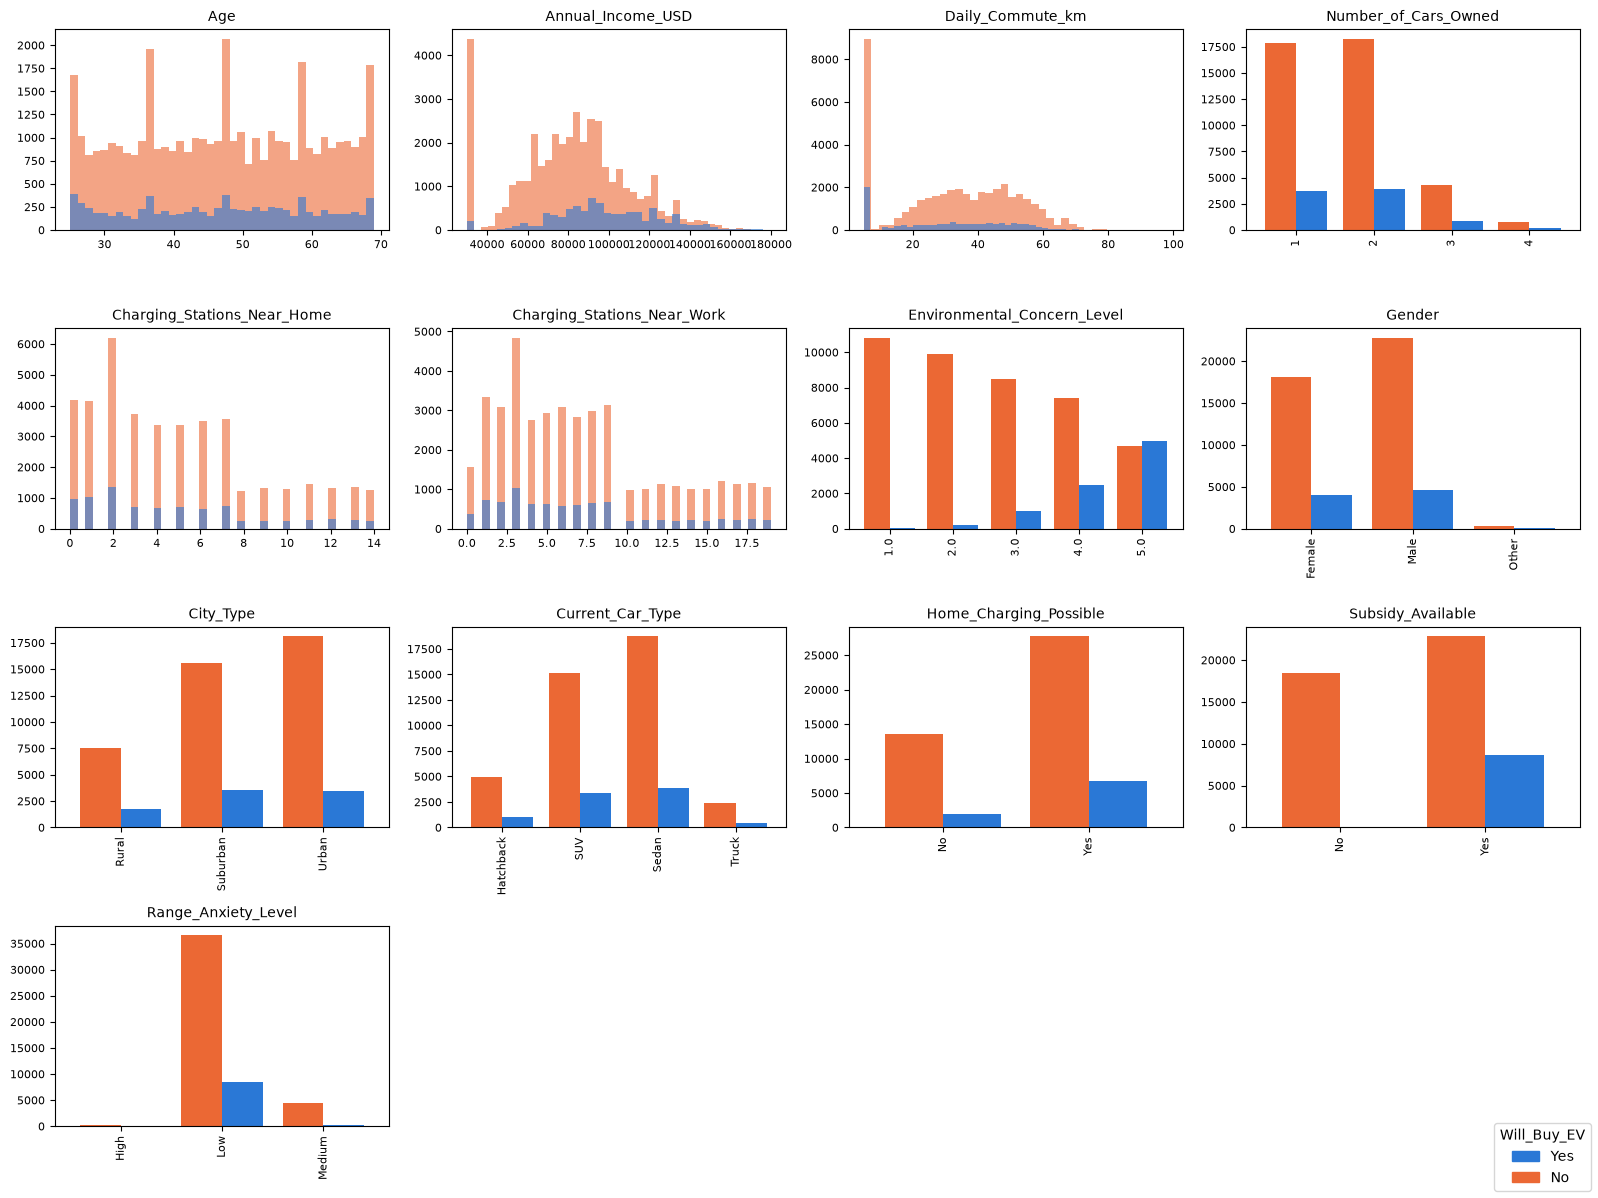

In [ ]:
# visual EDA
SAVE_PLOTS = False
s.plot_features(train, path='feature_plots.png' if SAVE_PLOTS else None)


In [ ]:
# statistic + visual EDA observations

# fourth quartile outliers - weighted emphasis required
# annual_income_usd 
# daily_commute_km

# right skew - log transformation:
# number_of_cars_owned
# charging_stations_near_home
# charging_stations_near_work

# high variance - consider smoothing:
# age? (see below)
# charging_stations_near_work

# low sample representation
# truck drivers - no
# ** subsidy is not available - yes
# gender "other" - yes/no

# further investigation
# age - not a variance issue. the "pillar" ages implies there is something about certain birthdays that prompt EV purchase...
# environmental concern level - appears a good predictor; false negative concern?

In [ ]:
# significance EDA
# permutation importance: quick fit on a sample, AUC drop when each feature is shuffled
importances = s.pi(train)
importances


Environmental_Concern_Level    0.1974
Subsidy_Available              0.1687
Annual_Income_USD              0.0280
Range_Anxiety_Level            0.0091
Daily_Commute_km               0.0010
Home_Charging_Possible         0.0005
Age                            0.0003
Charging_Stations_Near_Work    0.0001
Number_of_Cars_Owned           0.0001
City_Type                      0.0001
Charging_Stations_Near_Home    0.0001
Gender                         0.0000
Current_Car_Type              -0.0000
dtype: float64

In [ ]:
# significance EDA observations

# important predictors
# ** environmental_concern_level
# ** subsidy_abailable
# annual_income_usd
# range_anxiety_level

# little or no impact - removal candidates:
# gender
# current_car_type

# ** model relieas heavily on two predictors; bias risk
# gender - poorly represented "other" and little to no impact on model accuracy; stronger removal candidate

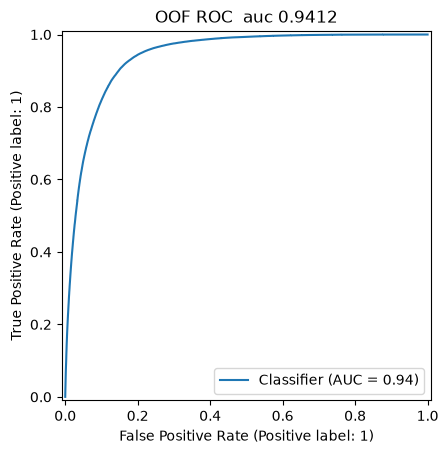

--- calibration by decile
     pred  actual      n
0  0.0003  0.0002  66867
1  0.0009  0.0006  66866
2  0.0031  0.0028  66867
3  0.0069  0.0065  66866
4  0.0124  0.0124  66867
5  0.0294  0.0277  66866
6  0.0867  0.0860  66866
7  0.2721  0.2726  66867
8  0.5409  0.5378  66866
9  0.7939  0.8000  66867
--- auc by category level
Gender                       Female     n= 295427  auc 0.9411
Gender                       Male       n= 367954  auc 0.9414
Gender                       Other      n=   5284  auc 0.9349
City_Type                    Rural      n= 123983  auc 0.9362
City_Type                    Suburban   n= 255377  auc 0.9405
City_Type                    Urban      n= 289305  auc 0.9438
Current_Car_Type             Hatchback  n=  79438  auc 0.9412
Current_Car_Type             SUV        n= 246545  auc 0.9398
Current_Car_Type             Sedan      n= 303459  auc 0.9424
Current_Car_Type             Truck      n=  39223  auc 0.9411
Home_Charging_Possible       No         n= 205988  au

In [16]:
# baseline oof - model bias / variance analysis
s.oof_report(X, y, oof)

In [ ]:
# baseline oof observations

# model bias
# ** model relies heavily on subsidy_available, but heavy false positives as well - strong bias candidate

## Train - Engineering

In [ ]:
# prep
X, cats = s.prep(train)
y = train[s.TARGET]
X.dtypes

Age                               int64
Annual_Income_USD               float64
Daily_Commute_km                float64
Number_of_Cars_Owned              int64
Charging_Stations_Near_Home       int64
Charging_Stations_Near_Work       int64
Environmental_Concern_Level     float64
Gender                         category
City_Type                      category
Current_Car_Type               category
Home_Charging_Possible         category
Subsidy_Available              category
Range_Anxiety_Level            category
dtype: object

In [ ]:
# engineering done in s6e9.py

# here's a review...

# downweight lower quartile outliers:
# ** annual_income_usd 
# ** daily_commute_km
# charging_stations_near_work

# right skew log transformations:
# ** number_of_cars_owned
# charging_stations_near_home
# charging_stations_near_work



In [ ]:
# train
models, oof = s.train(X, y)

In [26]:
# engineered score
models, oof = s.train(X, y)

fold 0  auc 0.94010  iters 268
fold 1  auc 0.94101  iters 265
fold 2  auc 0.94230  iters 229
fold 3  auc 0.94172  iters 308
fold 4  auc 0.94111  iters 220
oof auc 0.94123


In [ ]:
# engineered pi: same call, pass the engineered frame (must still contain the target column)
s.pi(train)


## Test

In [ ]:
X_test, _ = s.prep(test, cats)
sub = s.test(models, X_test, test[s.ID])
sub.head()